## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the data

In [4]:
df = pd.read_csv("train_genetic_disorders_cleaned.csv")

In [5]:
df.head()

,patient_age,maternal_gene_defect,paternal_gene_defect,maternal_gene,paternal_gene,status,respiratory_rate,heart_rate,follow_up,gender,...,assisted_conception,previous_pregnancy_anomalies,previous_abortions,birth_defects,blood_test_result,genetic_disorder,disorder_subclass,symptom_total,total_blood_cells,disorder_type
0,2.0,Yes,No,Yes,No,Alive,Normal (30-60),Normal,High,Missing,...,No,Yes,2.0,Multiple,slightly abnormal,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy,5,14.618166,Mitochondrial_genetic_inheritance_disorders_Le...
1,11.0,Yes,No,Yes,No,Alive,Normal (30-60),Tachycardia,Low,Male,...,Yes,No,4.0,Multiple,slightly abnormal,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy,5,13.678739,Mitochondrial_genetic_inheritance_disorders_Le...
2,10.0,Yes,Yes,Yes,Yes,Deceased,Normal (30-60),Tachycardia,Low,Female,...,Yes,No,0.0,Singular,slightly abnormal,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy,4,8.562090,Mitochondrial_genetic_inheritance_disorders_Le...
3,7.0,Yes,No,Yes,Yes,Deceased,Tachypnea,Normal,Low,Male,...,No,Yes,3.0,Multiple,normal,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy,4,13.748324,Mitochondrial_genetic_inheritance_disorders_Le...
4,13.0,Yes,Yes,Yes,Yes,Alive,Normal (30-60),Tachycardia,High,Female,...,No,No,4.0,Singular,slightly abnormal,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy,4,8.561366,Mitochondrial_genetic_inheritance_disorders_Le...


## Preliminary Data Exploration

#### Data Overview

In [6]:
df.shape

(18943, 27)

In [7]:
df.info

<bound method DataFrame.info of        patient_age maternal_gene_defect paternal_gene_defect maternal_gene  \
0              2.0                  Yes                   No           Yes   
1             11.0                  Yes                   No           Yes   
2             10.0                  Yes                  Yes           Yes   
3              7.0                  Yes                   No           Yes   
4             13.0                  Yes                  Yes           Yes   
...            ...                  ...                  ...           ...   
18938          9.0                  Yes                  Yes            No   
18939          2.0                  Yes                   No            No   
18940          8.0                   No                   No            No   
18941          2.0                   No                   No            No   
18942         11.0                   No                  Yes           Yes   

      paternal_gene    status r

In [8]:
df.describe()

,patient_age,previous_abortions,symptom_total,total_blood_cells
count,18943.000000,18943.000000,18943.000000,18943.000000
mean,6.950113,1.999842,2.633004,12.379289
std,4.179720,1.343595,1.235851,2.535277
min,0.000000,0.000000,0.000000,7.302273
25%,3.000000,1.000000,2.000000,10.548068
50%,7.000000,2.000000,3.000000,12.380474
75%,10.000000,3.000000,4.000000,14.184010
max,14.000000,4.000000,5.000000,17.536404


## Categorical Columns Overview
Helps understand the distribution of categories, identify missing values, and spot any imbalances in the data. This information is useful for data preprocessing and making informed decisions about encoding categorical variables.

In [9]:
categorical_cols = [
    'maternal_gene_defect', 'paternal_gene_defect', 'maternal_gene', 'paternal_gene',
    'status', 'respiratory_rate', 'heart_rate', 'follow_up', 'gender', 
    'birth_asphyxia', 'birth_defect_autopsy', 'birth_place', 'folic_acid_supplement',
    'maternal_illness_history', 'radiation_exposure_history', 'substance_abuse_history',
    'assisted_conception', 'previous_pregnancy_anomalies', 'previous_abortions',
    'birth_defects', 'blood_test_result', 'genetic_disorder', 'disorder_subclass',
    'disorder_type'
]

for col in categorical_cols:
    if col in df.columns:
        print(f"\nColumn: {col}")
        print(df[col].value_counts(dropna=False))



Column: maternal_gene_defect
maternal_gene_defect
Yes    11293
No      7650
Name: count, dtype: int64

Column: paternal_gene_defect
paternal_gene_defect
No     11505
Yes     7438
Name: count, dtype: int64

Column: maternal_gene
maternal_gene
Yes    10471
No      8472
Name: count, dtype: int64

Column: paternal_gene
paternal_gene
No     10725
Yes     8218
Name: count, dtype: int64

Column: status
status
Alive       9536
Deceased    9407
Name: count, dtype: int64

Column: respiratory_rate
respiratory_rate
Normal (30-60)    10340
Tachypnea          8603
Name: count, dtype: int64

Column: heart_rate
heart_rate
Normal         10171
Tachycardia     8772
Name: count, dtype: int64

Column: follow_up
follow_up
Low     9910
High    9033
Name: count, dtype: int64

Column: gender
gender
Male       6633
Missing    6232
Female     6078
Name: count, dtype: int64

Column: birth_asphyxia
birth_asphyxia
Missing    9257
Yes        5379
No         4307
Name: count, dtype: int64

Column: birth_defect_auto

## Univariate Analysis

#### Numerical Columns Distribution
For each column, it generates a histogram with a Kernel Density Estimate (KDE) curve, giving insights into the distribution and spread of the data. The histograms help identify skewness, potential outliers, and the overall distribution of each numeric feature.

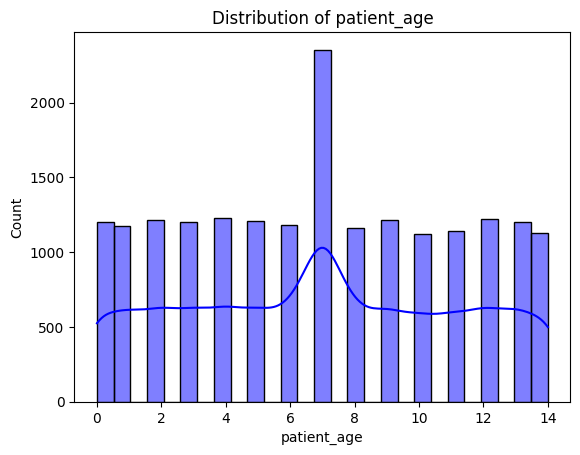

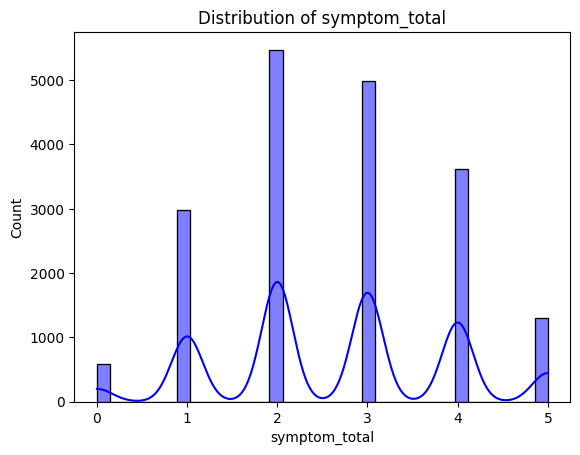

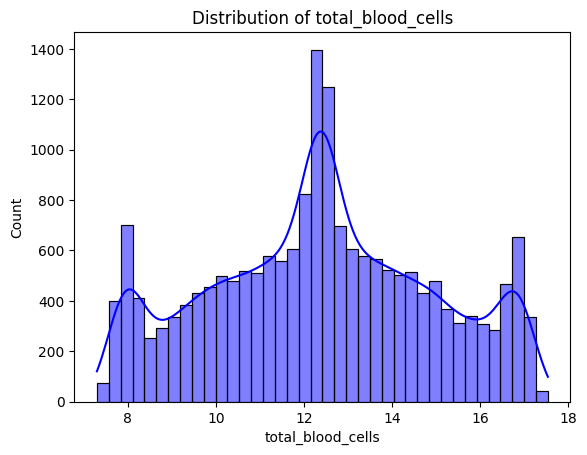

In [10]:
numeric_cols = ['patient_age', 'symptom_total', 'total_blood_cells']

for col in numeric_cols:
    if col in df.columns:
        plt.figure()
        sns.histplot(data=df, x=col, kde=True, color='blue')
        plt.title(f"Distribution of {col}")
        plt.show()

#### Target Variable Counts
Helps us understand the distribution of different categories within each target variable. By observing the count of each category, we can identify which disorders or subclasses are more prevalent. The distinct colors make each plot visually appealing while maintaining consistency.

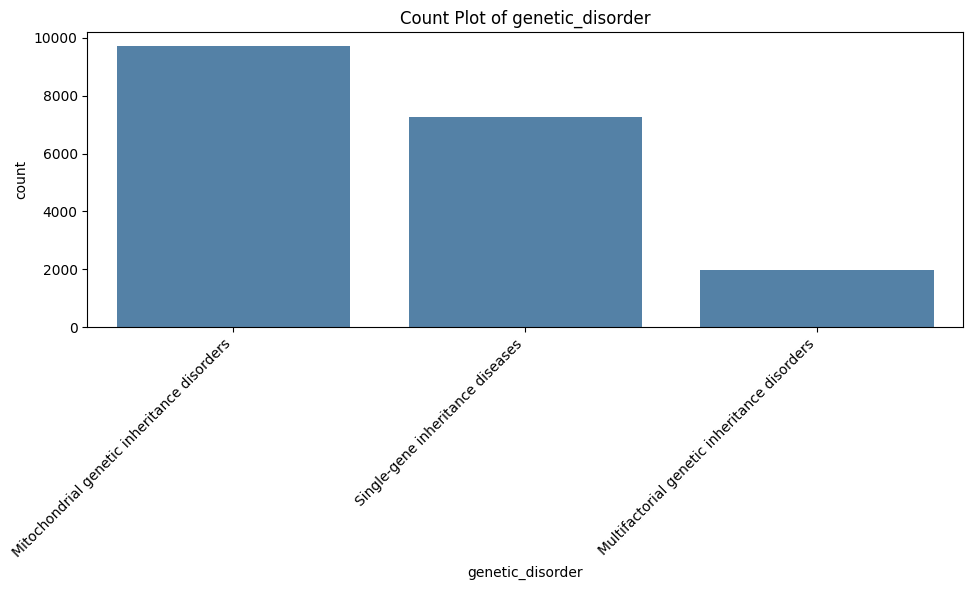

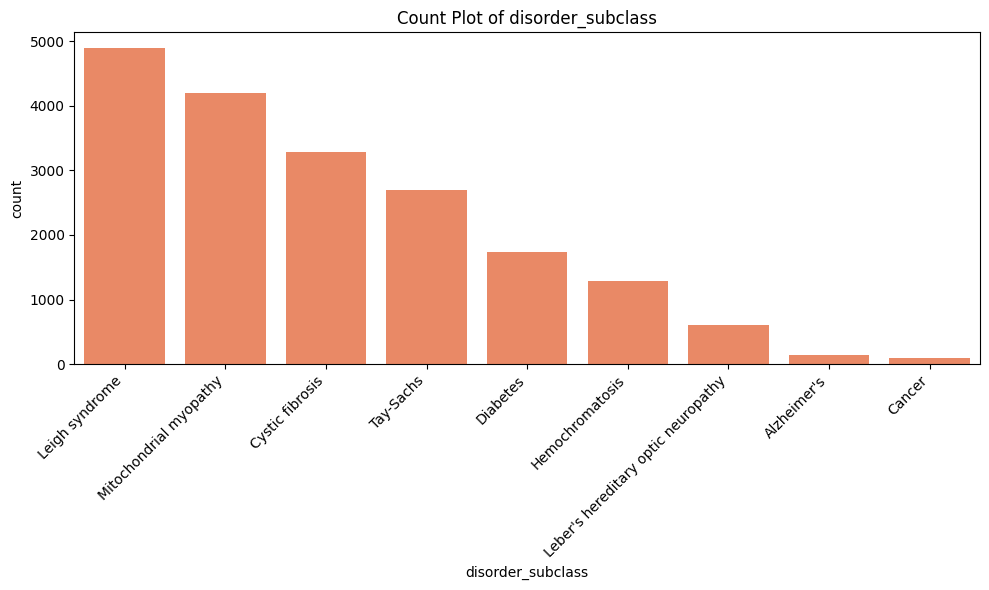

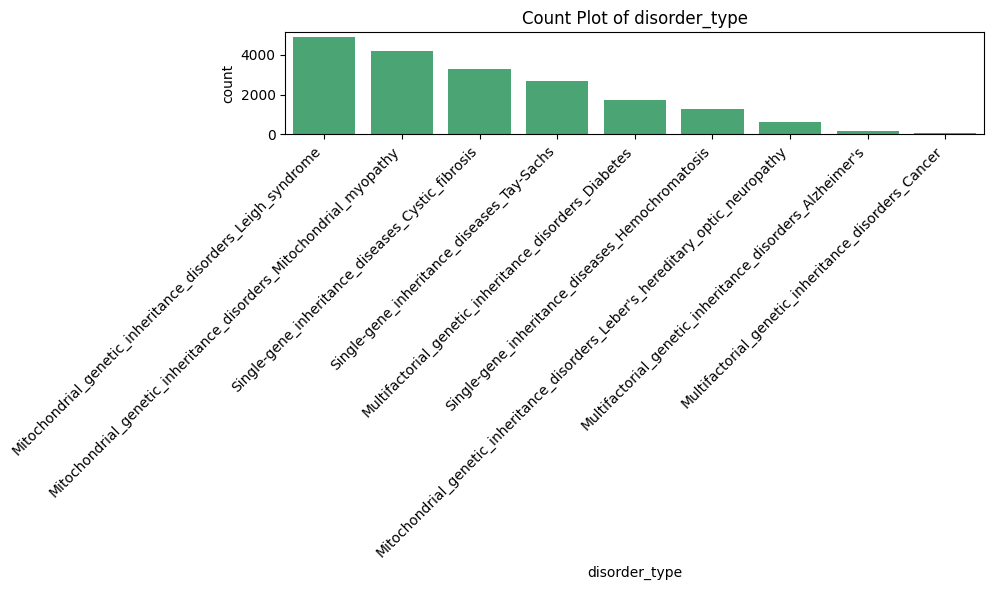

In [14]:
target_cols = ['genetic_disorder', 'disorder_subclass', 'disorder_type']
colors = ['steelblue', 'coral', 'mediumseagreen']

for i, col in enumerate(target_cols):
    if col in df.columns:
        plt.figure(figsize=(10, 6))  # Adjust figure size for better fit
        sns.countplot(
            data=df,
            x=col,
            order=df[col].value_counts().index,
            color=colors[i]
        )
        plt.title(f"Count Plot of {col}")
        plt.xticks(rotation=45, ha='right')
        plt.subplots_adjust(bottom=0.3)  # Adjust bottom margin for space
        plt.tight_layout()
        plt.show()


## Bivariate Analysis

#### Relationship Between Numeric Features
Generates a correlation heatmap for the numerical columns in the dataset, highlighting the relationships between them. The correlation values range from -1 to 1, where values close to 1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values near 0 imply no significant correlation. The heatmap provides a quick visual reference to identify highly correlated features, which can be useful for feature selection and understanding dependencies within the data.

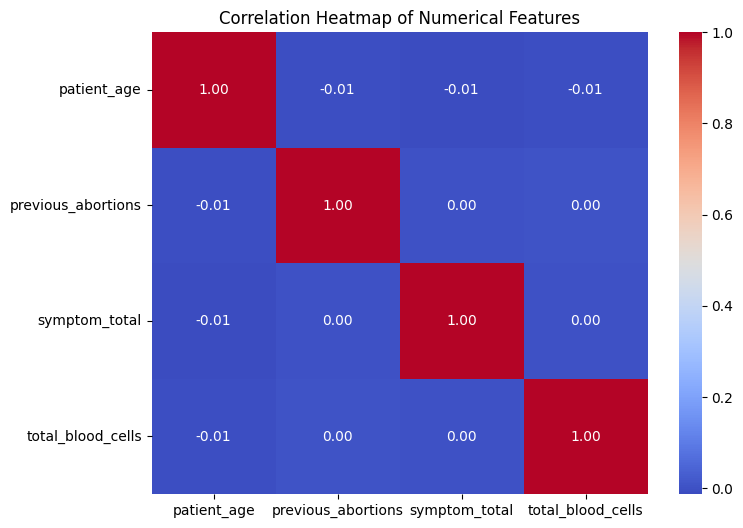

In [15]:
# Correlation matrix for numerical columns
numeric_data = df.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


#### Numeric Feature vs. Target Variables
#### 1
Shows the distribution of patient ages across different genetic disorders. Each box represents the age distribution for a specific disorder — with the median, quartiles, and potential outliers. This visualization helps in identifying if certain genetic disorders affect specific age groups more prominently.

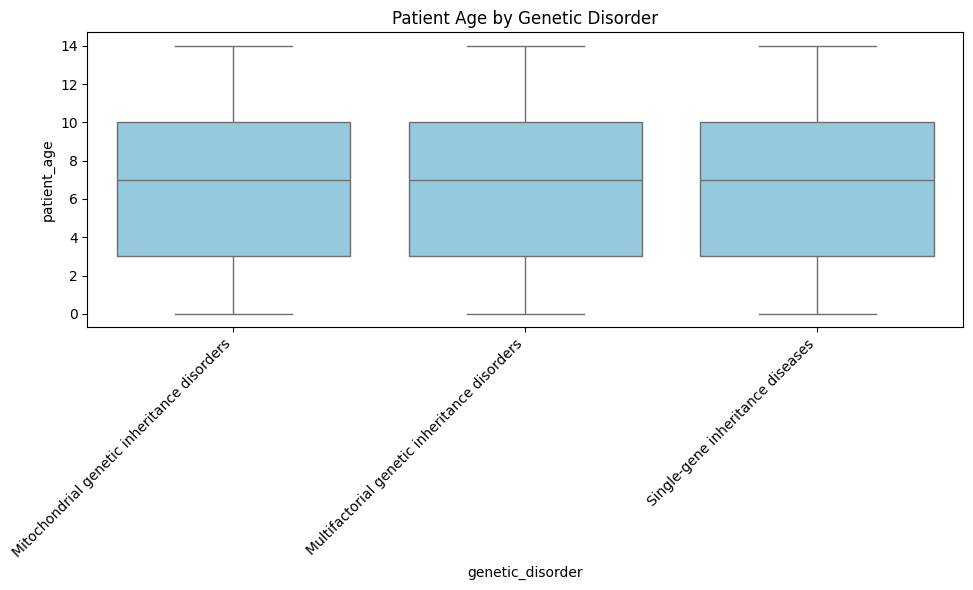

In [18]:
if 'genetic_disorder' in df.columns and 'patient_age' in df.columns:
    plt.figure(figsize=(10, 6))  
    sns.boxplot(data=df, x='genetic_disorder', y='patient_age', color='skyblue')  
    plt.title("Patient Age by Genetic Disorder")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()  
    plt.show()


#### 2
Compares the total blood cell counts across different disorder types. It helps identify if certain disorder types lead to higher or lower blood cell counts. The spread of data, potential outliers, and variations between disorder types provide insights into how these conditions might affect blood cell levels.

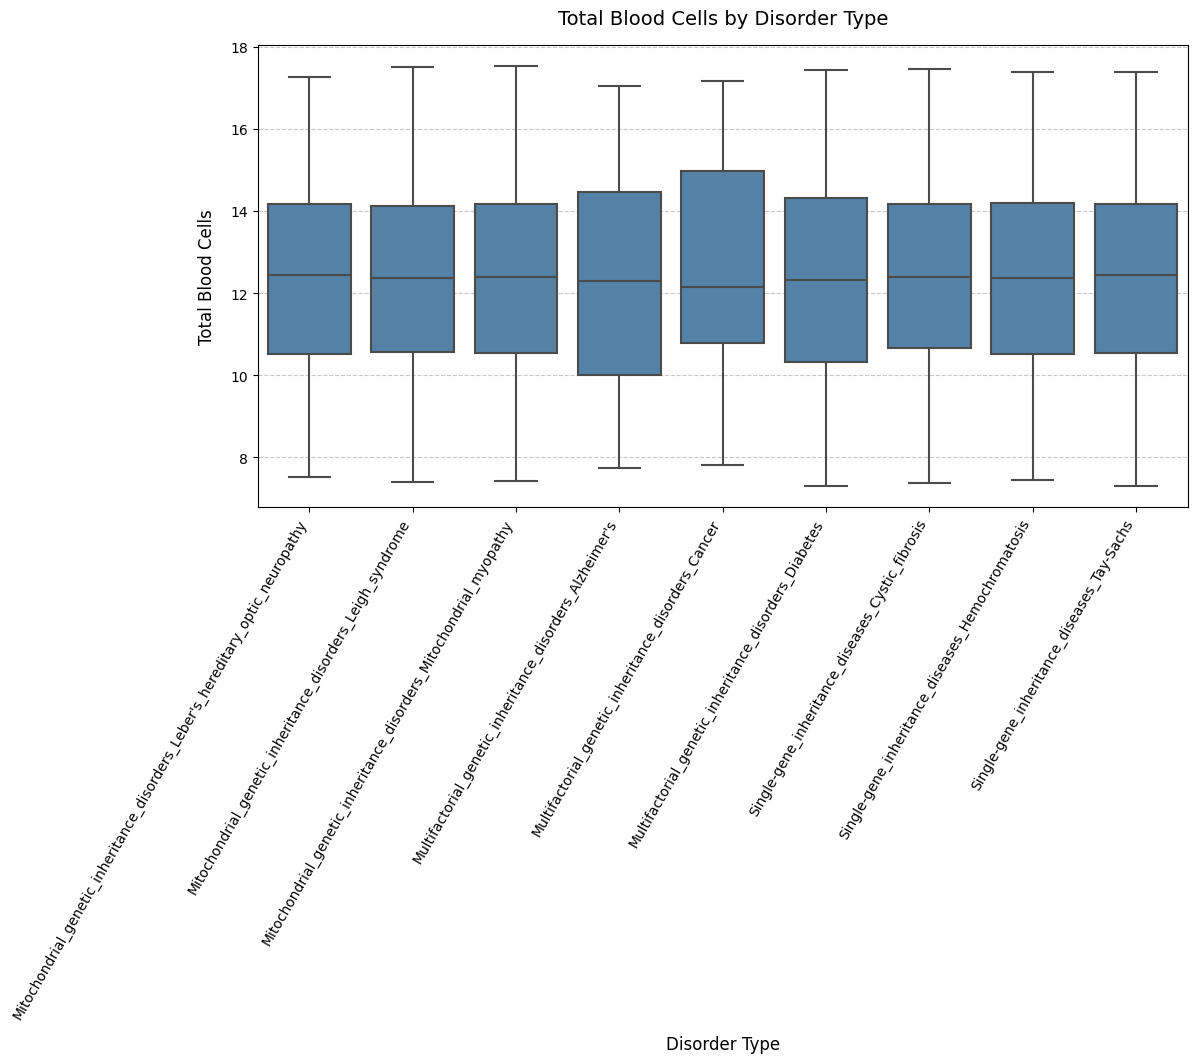

In [22]:
if 'disorder_type' in df.columns and 'total_blood_cells' in df.columns:
    plt.figure(figsize=(12, 6))  
    sns.boxplot(data=df, x='disorder_type', y='total_blood_cells', color='#4682B4', linewidth=1.5)  
    plt.title("Total Blood Cells by Disorder Type", fontsize=14, pad=15) 
    plt.xticks(rotation=60, ha='right', fontsize=10)  
    plt.yticks(fontsize=10) 
    plt.xlabel("Disorder Type", fontsize=12, labelpad=10)  
    plt.ylabel("Total Blood Cells", fontsize=12, labelpad=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  
    plt.show()


## Categorical Feature Interactions

#### Gene Defect vs. Genetic Disorder
Explores the relationship between maternal gene defects and genetic disorders using a cross-tabulation. The cross-tab table shows the frequency of each genetic disorder type for different maternal gene defect categories. The stacked bar plot visually displays this relationship, helping identify any patterns or associations between maternal gene defects and genetic disorders. If certain genetic disorders are more frequent in specific defect categories, it can indicate a potential link worth exploring further.

Cross-tab: Maternal Gene Defect vs. Genetic Disorder
genetic_disorder      Mitochondrial genetic inheritance disorders  \
maternal_gene_defect                                                
No                                                           4032   
Yes                                                          5670   

genetic_disorder      Multifactorial genetic inheritance disorders  \
maternal_gene_defect                                                 
No                                                             532   
Yes                                                           1451   

genetic_disorder      Single-gene inheritance diseases  
maternal_gene_defect                                    
No                                                3086  
Yes                                               4172  


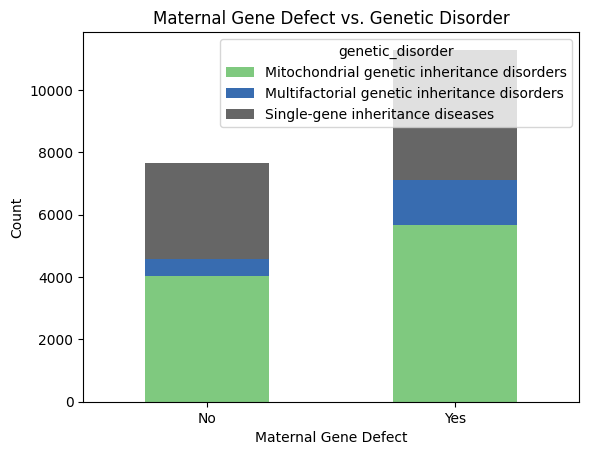

In [24]:
if 'maternal_gene_defect' in df.columns and 'genetic_disorder' in df.columns:
    cross_tab = pd.crosstab(df['maternal_gene_defect'], df['genetic_disorder'])
    print("Cross-tab: Maternal Gene Defect vs. Genetic Disorder")
    print(cross_tab)

    cross_tab.plot(kind='bar', stacked=True, cmap='Accent')
    plt.title("Maternal Gene Defect vs. Genetic Disorder")
    plt.xlabel("Maternal Gene Defect")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

#### Birth Asphyxia vs. Disorder Subclass
Analyzes the relationship between birth asphyxia and different disorder subclasses. The cross-tabulation table displays the count of each disorder subclass categorized by the presence or absence of birth asphyxia. The stacked bar chart visually represents these counts, helping identify if certain disorder subclasses are more prevalent among individuals with or without birth asphyxia. Recognizing patterns here can offer insights into potential correlations between birth complications and specific genetic conditions.

Cross-tab: Birth Asphyxia vs. Disorder Subclass
disorder_subclass  Alzheimer's  Cancer  Cystic fibrosis  Diabetes  \
birth_asphyxia                                                      
Missing                     77      35             1485       940   
No                          35      33              723       393   
Yes                         36      24             1069       410   

disorder_subclass  Hemochromatosis  Leber's hereditary optic neuropathy  \
birth_asphyxia                                                            
Missing                        572                                  342   
No                             429                                  122   
Yes                            290                                  143   

disorder_subclass  Leigh syndrome  Mitochondrial myopathy  Tay-Sachs  
birth_asphyxia                                                        
Missing                      2698                    1885       1223  
No               

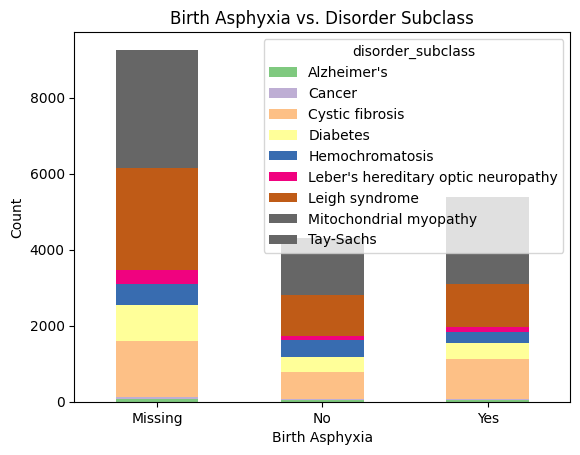

In [25]:
if 'birth_asphyxia' in df.columns and 'disorder_subclass' in df.columns:
    cross_tab = pd.crosstab(df['birth_asphyxia'], df['disorder_subclass'])
    print("Cross-tab: Birth Asphyxia vs. Disorder Subclass")
    print(cross_tab)

    cross_tab.plot(kind='bar', stacked=True, cmap='Accent')
    plt.title("Birth Asphyxia vs. Disorder Subclass")
    plt.xlabel("Birth Asphyxia")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()
